
# Level 1 -- Your First Sensor2EventLog Run, Step by Step 🚀

**Coming from [Level 0](../tutorials/level_0_concepts/level_0_concepts.ipynb)?** Good -- you already know what
an event log is, why raw sensor data isn't one, and what process discovery does. Time to close that gap
yourself, one small, explained piece at a time.

Unlike a lot of tutorials, we are *not* going to hand you one big block of code and say "run this." Every piece
of code below is preceded by an explanation of *why* it exists, and most sections include a small "guess before
you run it" question, so you're reasoning about the pipeline, not just executing it.

**🎯 Learning objectives.** By the end of this notebook, you should be able to:

1. Explain, for a real batch industrial process, what each of the six feature families in Sensor2EventLog
   actually computes -- in your own words, not just by name.
2. Predict, roughly, what a rule like `(T > 70) & (T_stable_flag == 1)` will and won't catch, before running it.
3. Run the full Sensor2EventLog pipeline end to end and correctly interpret its output.
4. Know where to find real industrial sensor datasets if you want to practice further on your own.

> 📓 **A Python script version of this exact walkthrough** is available at `tutorial/toy_walkthrough.py`, if you
> prefer running things outside a notebook.



## Step 1 -- Setup

Point Python at the repository root so `core`, `features`, `models`, and friends import correctly, no matter
where you launched this notebook from.


In [1]:

import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "features").exists():
            return candidate
    raise RuntimeError("Could not locate the Sensor2EventLog repository root.")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", 20)

print("Repo root:", repo_root)


Repo root: /home/claude/Sensor2EventLog



✅ **What you should observe:** a single line printing the path to your cloned `Sensor2EventLog` repository, and
no import errors.



## Step 2 -- The scenario, in physical terms

We're going to simulate a **batch pasteurization process** -- the same kind of process behind a vat like this
one:

![A stainless steel milk vat used for pasteurization](https://commons.wikimedia.org/wiki/Special:FilePath/Milk_Vat.jpg)

*Milk vat photo: Wikimedia Commons (public domain).*

Product goes in, gets heated to a target temperature, held there long enough to kill pathogens, then cooled and
discharged. The heating and cooling in a real plant usually happens through a **heat exchanger** -- product on
one side, hot or cold utility fluid on the other, separated by a wall that transfers heat without mixing them:

![Diagram of a shell-and-tube heat exchanger](https://commons.wikimedia.org/wiki/Special:FilePath/U-tube_heat_exchanger.PNG)

*Heat exchanger diagram: Wikimedia Commons (public domain).*

Three sensors give us everything we need for this tutorial: a **temperature probe** (`T`), an **inlet flow
meter** (`Q_in`), and an **outlet flow meter** (`Q_out`). The process always visits the same six states in the
same order:

| State | What's physically happening | Expected sensor signature |
|---|---|---|
| Idle | Tank empty | T flat at ambient, both flows ~0 |
| Fill | Tank filling | Q_in high, T still near ambient |
| HeatUp | Heat exchanger warming the product | T rising steadily |
| Hold | Held at pasteurization temperature | T flat and high, both flows low |
| Cool | Heat exchanger cooling the product | T falling, Q_out starts rising |
| Discharge | Tank emptying | Q_out high, T settling back to ambient |

> 🔗 **Curious what *real* industrial sensor data looks like, beyond our simulation?** Two well-known, freely
> available datasets: NASA's [C-MAPSS turbofan engine degradation dataset](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/)
> (21 real sensor channels per engine, run-to-failure trajectories) and the
> [Smart Manufacturing IoT-Cloud dataset](https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset)
> we used in Level 0. Both are good practice material once you've finished this notebook.

We'll build our simulation in small pieces, explaining each one, rather than dropping one big function on you.



### Step 3a -- Encode the states and their durations

First, just the process structure: the order of states, and roughly how many sampling steps (one per minute,
say) each one lasts. Notice `Fill` and `HeatUp` are the longest -- moving and heating a full tank of liquid
takes real time, while `Idle` and `Discharge` are comparatively quick.


In [2]:

STATE_ORDER = ["Idle", "Fill", "HeatUp", "Hold", "Cool", "Discharge"]
STATE_DURATIONS = {"Idle": 3, "Fill": 5, "HeatUp": 5, "Hold": 4, "Cool": 4, "Discharge": 3}
STATE_DURATIONS


{'Idle': 3, 'Fill': 5, 'HeatUp': 5, 'Hold': 4, 'Cool': 4, 'Discharge': 3}


### Step 3b -- Describe each state's sensor signature

**🧠 Quick check, before you look at the code below:** during `Cool`, what would you predict `Q_out` does --
stays near zero, or rises? What about `T`?

<details>
<summary>Click to compare notes</summary>

`T` should be *falling* (that's the definition of cooling), and `Q_out` should start *rising*, because cooled
product is already being drawn off toward discharge in a continuously-operated line. If your intuition said
"T falls, Q_out rises" -- you've essentially just derived the function below yourself.
</details>

Here's that logic as code -- one small function, one state at a time:


In [3]:

def _state_profile(state, step, total_steps, batch_offset):
    """Return the *expected* (noise-free) sensor values for one state, at one point in time."""
    progress = step / max(total_steps - 1, 1)  # 0.0 at the start of the state, 1.0 at the end
    if state == "Idle":
        return {"T": 24 + batch_offset, "Q_in": 0.0, "Q_out": 0.0}
    if state == "Fill":
        return {"T": 24 + batch_offset, "Q_in": 0.75, "Q_out": 0.02}
    if state == "HeatUp":
        return {"T": 30 + 42 * progress + batch_offset, "Q_in": 0.35, "Q_out": 0.0}
    if state == "Hold":
        return {"T": 73 + batch_offset, "Q_in": 0.08, "Q_out": 0.03}
    if state == "Cool":
        return {"T": 73 - 33 * progress + batch_offset, "Q_in": 0.05, "Q_out": 0.18}
    if state == "Discharge":
        return {"T": 37 + batch_offset, "Q_in": 0.0, "Q_out": 0.72}
    raise ValueError(state)

# Sanity check: T should climb steadily across HeatUp
for step in range(5):
    print(step, "->", _state_profile("HeatUp", step, total_steps=5, batch_offset=0))


0 -> {'T': 30.0, 'Q_in': 0.35, 'Q_out': 0.0}
1 -> {'T': 40.5, 'Q_in': 0.35, 'Q_out': 0.0}
2 -> {'T': 51.0, 'Q_in': 0.35, 'Q_out': 0.0}
3 -> {'T': 61.5, 'Q_in': 0.35, 'Q_out': 0.0}
4 -> {'T': 72.0, 'Q_in': 0.35, 'Q_out': 0.0}



✅ **What you should observe:** `T` climbing from 30 up towards 72 across the five printed steps, matching the
"T rising steadily" row in our state table above. `progress` is what does the climbing -- it's just a 0-to-1
ramp across the state's duration.

### Step 3c -- Add realistic sensor noise

Real sensors are never perfectly clean -- there's electrical noise, tiny physical fluctuations, calibration
imprecision. We add independent Gaussian noise to each sensor reading, separately, at each timestamp.

**🧠 Quick check:** why add noise *separately* to `T`, `Q_in`, and `Q_out`, instead of generating one shared
noise value and adding it to all three?

<details>
<summary>Click to compare notes</summary>

Because in reality, temperature noise and flow noise come from physically unrelated sources (a thermocouple's
electrical noise has nothing to do with a flow meter's turbulence). Sharing one noise source across all three
sensors would create a fake correlation between them that doesn't exist in a real plant -- and could make our
`interaction` features (Step 5) look artificially more informative than they'd be on real data.
</details>

### Step 3d -- Add batch-to-batch variation

No two real batches are identical -- incoming product temperature drifts through the day, sensors drift between
recalibrations, and so on. We model this with a small constant offset, different for each batch, added to every
temperature reading in that batch.

### Step 3e -- Put it all together

Now we combine all three ideas -- state structure, per-state signatures, noise, and batch variation -- into one
function that generates a complete synthetic dataset.


In [4]:

def make_toy_dataset(n_batches=3, random_seed=7):
    rng = np.random.default_rng(random_seed)
    rows = []
    for batch_num in range(1, n_batches + 1):
        batch_id = f"batch_{batch_num:02d}"
        batch_offset = 0.4 * (batch_num - 1)  # Step 3d: each batch runs slightly warmer than the last
        timestamp = 0
        for state in STATE_ORDER:
            duration = STATE_DURATIONS[state]
            for step in range(duration):
                profile = _state_profile(state, step, duration, batch_offset)
                rows.append({
                    "batch_id": batch_id,
                    "timestamp": timestamp,
                    "state": state,
                    # Step 3c: independent noise added to each sensor
                    "T": round(profile["T"] + rng.normal(0, 0.45), 3),
                    "Q_in": max(0.0, round(profile["Q_in"] + rng.normal(0, 0.03), 3)),
                    "Q_out": max(0.0, round(profile["Q_out"] + rng.normal(0, 0.03), 3)),
                })
                timestamp += 60
    return pd.DataFrame(rows)


raw_df = make_toy_dataset(n_batches=3)
print(f"{len(raw_df)} rows across {raw_df['batch_id'].nunique()} batches")
raw_df.head(8)


72 rows across 3 batches


,batch_id,timestamp,state,T,Q_in,Q_out
0,batch_01,0,Idle,24.001,0.009,0.000
1,batch_01,60,Idle,23.599,0.000,0.000
2,batch_01,120,Idle,24.027,0.040,0.000
3,batch_01,180,Fill,23.721,0.765,0.031
4,batch_01,240,Fill,24.047,0.722,0.019
5,batch_01,300,Fill,24.313,0.710,0.006
6,batch_01,360,Fill,23.144,0.711,0.000
7,batch_01,420,Fill,23.894,0.712,0.028



✅ **What you should observe:** 72 rows across 3 batches, columns `batch_id, timestamp, state, T, Q_in, Q_out`.
`state` is our ground truth, included so we can check our work later -- pretend, for a moment, that it doesn't
exist, because a real deployment usually starts without it.



## Step 4 -- Look at the raw data

Back in Level 0 we asked: could you tell the process state just by eyeballing `T`, `Q_in`, `Q_out`? Let's look
at a real trace and judge for ourselves.


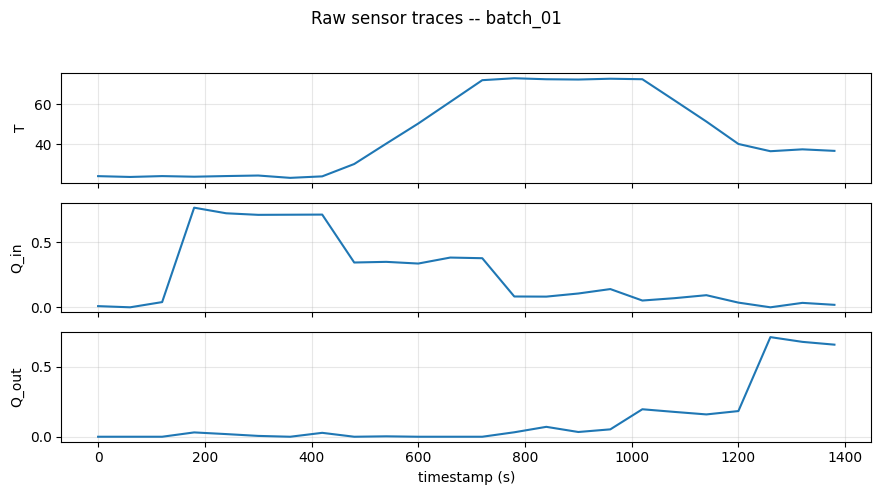

In [5]:

def plot_raw_batch(df, batch_id, cols=("T", "Q_in", "Q_out")):
    batch_df = df[df["batch_id"] == batch_id].sort_values("timestamp")
    fig, axes = plt.subplots(len(cols), 1, figsize=(9, 5), sharex=True)
    for ax, col in zip(axes, cols):
        ax.plot(batch_df["timestamp"], batch_df[col], linewidth=1.5)
        ax.set_ylabel(col)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("timestamp (s)")
    fig.suptitle(f"Raw sensor traces -- {batch_id}")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_raw_batch(raw_df, "batch_01")



**🧠 Quick check:** find the point where `T` stops rising and flattens out near its peak. What state transition
is that boundary marking?

<details>
<summary>Click to check your reasoning</summary>

That's the `HeatUp -> Hold` boundary -- `T` climbs during `HeatUp` and then flattens once the target
pasteurization temperature is reached and held. You can probably also spot `Fill -> HeatUp` (where `Q_in` drops
back down as filling finishes) reasonably confidently. What's much harder to spot by eye: the *exact* boundary
between `Idle` and the very start of `Fill`, or between `Cool` and `Discharge` -- both involve a flow signal
easing from near-zero to noticeably-nonzero, buried in the same noise band. That ambiguity is exactly why we
need engineered features, not raw thresholds, next.
</details>



## Step 5 -- Feature engineering, one family at a time

Sensor2EventLog's abstraction layer (`features/feature_library.py`) computes six families of features. Rather
than show you the whole thing at once, let's build a tiny, standalone example of each one first, on a made-up
6-number series -- so you understand *what each family does* before we point it at our real data.


In [6]:

demo = pd.Series([24.0, 24.2, 24.1, 30.5, 41.0, 55.5], name="T_demo")
demo


0    24.0
1    24.2
2    24.1
3    30.5
4    41.0
5    55.5
Name: T_demo, dtype: float64


### `statistical` -- "what's the recent typical level?"

A rolling mean over a window -- smooths out noise so a single wild reading doesn't fool anything downstream.


In [7]:

demo.rolling(window=3, min_periods=1).mean()


0    24.000000
1    24.100000
2    24.100000
3    26.266667
4    31.866667
5    42.333333
Name: T_demo, dtype: float64


### `temporal` -- "is it rising, falling, or flat, and how fast?"

The simplest version is just the difference between consecutive readings.


In [8]:

demo.diff().fillna(0)


0     0.0
1     0.2
2    -0.1
3     6.4
4    10.5
5    14.5
Name: T_demo, dtype: float64


Notice the jump from `0.1` to `6.4` between index 2 and 3 -- that's `demo` starting to climb quickly, exactly
where `HeatUp` would begin in a real trace.

### `stability` -- "has this signal settled down?"

A binary flag: is the absolute change since last reading below some small threshold `eps`?


In [9]:

eps = 1.0
(demo.diff().fillna(0).abs() < eps).astype(int)


0    1
1    1
2    1
3    0
4    0
5    0
Name: T_demo, dtype: int64


Flags `1` for the first three (quiet, `Idle`-like) readings, and `0` once the big jump happens -- exactly the
`T_stable_flag` feature our `hold_rule` will lean on later.

### `interaction` -- "how do two signals relate to each other?"

Products and ratios between pairs of signals. Here's a tiny example against a matching flow-like series:


In [10]:

flow_demo = pd.Series([0.0, 0.0, 0.02, 0.30, 0.35, 0.05], name="Q_in_demo")
pd.DataFrame({"product": demo * flow_demo, "ratio": demo / flow_demo.replace(0, np.nan)})


,product,ratio
0,0.000,NaN
1,0.000,NaN
2,0.482,1205.000000
3,9.150,101.666667
4,14.350,117.142857
5,2.775,1110.000000



(The real implementation uses a slightly more careful log-based ratio to avoid blowing up near zero -- this
simple version is just for building intuition.)

### `event` -- "does this timestamp match an expert-defined rule?"

This is where domain knowledge enters directly, as a **boolean rule expressed over other features**:


In [11]:

demo_df = pd.DataFrame({"T": demo, "T_stable_flag": (demo.diff().fillna(0).abs() < eps).astype(int)})
demo_df["hold_candidate"] = (demo_df["T"] > 30) & (demo_df["T_stable_flag"] == 1)
demo_df


,T,T_stable_flag,hold_candidate
0,24.0,1,False
1,24.2,1,False
2,24.1,1,False
3,30.5,0,False
4,41.0,0,False
5,55.5,0,False



No row satisfies `hold_candidate` here -- makes sense, since our tiny demo series never actually gets both hot
*and* stable at the same time. That combination -- "high AND stable" -- is precisely the `hold_rule` we'll use
in the real feature plan in a moment.

> ⚠️ **One real constraint worth knowing up front:** a rule can reference the raw signal plus a fixed,
> automatically computed set of per-signal helpers (`{signal}_diff`, `{signal}_diff_smooth`, `{signal}_abs_diff`,
> `{signal}_stability`, `{signal}_stable_flag}`) -- not arbitrary features from other families. If you reference
> a name outside that set, the rule silently evaluates to all-`False` rather than raising an error, which is
> worth watching for the first few times you write one.

### `contextual` -- "where are we within the batch?"

A signal's *position* within its case can matter as much as its value -- e.g. a temperature reading near the
very start of a batch means something different than the same reading near the end.


In [12]:

toy_batch = pd.DataFrame({"batch_id": ["b1"] * 4 + ["b2"] * 3})
position = toy_batch.groupby("batch_id").cumcount()
max_position = position.groupby(toy_batch["batch_id"]).transform("max")
toy_batch.assign(batch_position=position / max_position)


,batch_id,batch_position
0,b1,0.000000
1,b1,0.333333
2,b1,0.666667
3,b1,1.000000
4,b2,0.000000
5,b2,0.500000
6,b2,1.000000



`batch_position` runs from `0.0` (first reading of the batch) to `1.0` (last reading), independently for each
`batch_id` -- exactly what `is_batch_start` / `is_batch_end` style features build on.

### Assembling the real feature plan

Now that each family makes sense on its own, here's the feature plan we'll actually use on `raw_df`:


In [13]:

feature_plan = {
    "statistical": ["T", "Q_in", "Q_out"],
    "temporal": ["T", "Q_in", "Q_out"],
    "stability": ["T"],
    "interaction": [["T", "Q_in"], ["T", "Q_out"]],
    "event": [
        {"fill_rule": "(Q_in > 0.5) & (Q_out < 0.1)"},
        {"hold_rule": "(T > 70) & (T_stable_flag == 1)"},
        {"discharge_rule": "(Q_out > 0.5) & (Q_in < 0.1)"},
    ],
    "contextual": ["batch_position"],
}
feature_plan


{'statistical': ['T', 'Q_in', 'Q_out'],
 'temporal': ['T', 'Q_in', 'Q_out'],
 'stability': ['T'],
 'interaction': [['T', 'Q_in'], ['T', 'Q_out']],
 'event': [{'fill_rule': '(Q_in > 0.5) & (Q_out < 0.1)'},
  {'hold_rule': '(T > 70) & (T_stable_flag == 1)'},
  {'discharge_rule': '(Q_out > 0.5) & (Q_in < 0.1)'}],
 'contextual': ['batch_position']}


Compare `hold_rule` here with the `hold_candidate` mini-demo above -- same idea (`T` high AND stable), just
tuned to our real temperature scale (`> 70`, since our pasteurization hold temperature is ~73°C, not the toy
demo's made-up numbers).


In [14]:

from features.feature_library import ModularFeatureLibrary

feature_library = ModularFeatureLibrary(window_sizes=[5], stability_eps=1, peak_threshold=0.1)
features = feature_library.compute_features(raw_df, feature_plan)
print(f"{features.shape[1]} engineered columns from 3 raw signals")

event_cols = [c for c in features.columns if c.startswith("event_")]
features[event_cols].sum().rename("times each rule fired")


Created named event feature: event_fill_rule
Created named event feature: event_hold_rule
Created named event feature: event_discharge_rule
28 engineered columns from 3 raw signals


event_fill_rule         15
event_hold_rule         13
event_discharge_rule     9
Name: times each rule fired, dtype: int64


✅ **What you should observe:** roughly 28 engineered columns from just 3 raw signals -- that expansion, from 3
numbers per timestamp to ~28, is the abstraction layer doing its job. `fill_rule` and `discharge_rule` should
each fire double digits of times (once per matching timestamp across all 3 batches); `hold_rule` similarly.



## Step 6 -- Run the full pipeline

Here's the conceptual roadmap for what happens next, before we run any code:

1. **Feature extraction** -- exactly what we just did by hand above, done automatically.
2. **HMM training** -- a Hidden Markov Model learns which feature patterns correspond to which hidden state,
   and how states tend to follow each other.
3. **Event log generation** -- the model's per-timestamp predictions get collapsed into clean intervals.

**🧠 Quick check, before running:** we have 3 batches x 6 states = 18 "true" state segments in total. Do you
expect the pipeline to recover *exactly* 18 events, more, or fewer? (No wrong answer yet -- just form a
prediction.)

<details>
<summary>Click to compare notes after you've formed a guess</summary>

In an ideal world, exactly 18. In practice, keep an eye out below -- unsupervised HMM decoding on a dataset this
small often "flickers" a little (briefly misclassifying a timestamp before correcting itself), which inflates
the count above 18. That's not a bug; it's a realistic symptom of eventization on noisy, limited data, and one
you'll see and interpret directly in a moment.
</details>


In [15]:

import types
import config as base_config
from core.pipeline import Sensor2EventLogPipeline

dataset_path = Path("level1_toy_data.csv")
raw_df.to_csv(dataset_path, index=False)

cfg = types.SimpleNamespace(**{k: v for k, v in base_config.__dict__.items() if k.isupper()})
cfg.PATHS = {"event_log": "level1_event_log.csv", "filtered_log": "level1_event_log_filtered.csv"}

pipeline = Sensor2EventLogPipeline(cfg)
result = pipeline.run(
    data_path=str(dataset_path),
    feature_plan=feature_plan,
    mode="unsupervised",
    n_unsup=len(STATE_ORDER),
    random_seed=42,
    return_intermediate=True,
    min_duration_seconds=0.0,
)

print("Pipeline finished. Result keys:", list(result.keys()))


Created named event feature: event_fill_rule
Created named event feature: event_hold_rule
Created named event feature: event_discharge_rule

Training unsupervised HMM...

== Unsupervised HMM (mapped) — Test ==
              precision    recall  f1-score   support

        Idle       1.00      0.33      0.50         6
        Fill       0.50      1.00      0.67        10
      HeatUp       1.00      0.60      0.75        10
        Hold       0.75      0.75      0.75         8
        Cool       0.60      0.75      0.67         8
   Discharge       1.00      0.33      0.50         6

    accuracy                           0.67        48
   macro avg       0.81      0.63      0.64        48
weighted avg       0.79      0.67      0.66        48

Confusion matrix (rows=true, cols=pred):
           Idle  Fill  HeatUp  Hold  Cool  Discharge
Idle          2     4       0     0     0          0
Fill          0    10       0     0     0          0
HeatUp        0     4       6     0     0      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



✅ **What you should observe:** some printed feature-creation messages, a short training log ending in
`"Training unsupervised HMM..."`, then a per-state precision/recall table, and finally the summary line above
listing `event_log, model, predictions, features, diagnostics` as the result keys.



## Step 7 -- Diagnostics: which states are we explaining well?

`return_intermediate=True` means we also got back the rule diagnostics -- the same coverage/precision scoring
idea from Level 0's "process discovery" discussion, applied here to our own rules.


In [16]:

diagnostics = result["diagnostics"]
print("States our current rules struggle to explain:", diagnostics["unexplainable_states"])
print(f"{len(diagnostics['recommendations'])} improvement recommendations generated")


States our current rules struggle to explain: ['Idle', 'HeatUp', 'Cool']
18 improvement recommendations generated



**🧠 Quick check:** looking back at Step 5's feature plan, we wrote rules for `fill_rule`, `hold_rule`, and
`discharge_rule` only. Which three states would you *predict* show up as "unexplainable" here, before reading
the printed list above?

<details>
<summary>Click to compare notes</summary>

`Idle`, `HeatUp`, and `Cool` -- the three states we never wrote a rule for. This isn't a failure of the pipeline;
the HMM in Step 6 still decodes *all six* states using the underlying engineered features, even without an
explicit rule for a given state. Writing better rules to close gaps like this -- the actual Machine Teaching
loop -- gets a full notebook of its own in Level 2.
</details>



## Step 8 -- The event log itself

This is the payoff: a real, segmented, `(case, activity, timestamp)`-shaped event log, decoded from nothing but
raw sensor readings and the small feature plan above.


In [17]:

event_log = result["event_log"]
print(event_log)
event_log.to_dataframe()


EventLog(cases=3, events=29, activities=6)


,case_id,activity_sequence,activity,start_timestamp,end_timestamp,duration_seconds,event_count
0,batch_01,1,Idle,2023-01-01 00:00:00,2023-01-01 00:02:00,120.0,3
1,batch_01,2,Fill,2023-01-01 00:03:00,2023-01-01 00:05:00,120.0,3
2,batch_01,3,HeatUp,2023-01-01 00:06:00,2023-01-01 00:06:00,0.0,1
3,batch_01,4,Fill,2023-01-01 00:07:00,2023-01-01 00:07:00,0.0,1
4,batch_01,5,HeatUp,2023-01-01 00:08:00,2023-01-01 00:08:00,0.0,1
5,batch_01,6,Fill,2023-01-01 00:09:00,2023-01-01 00:09:00,0.0,1
6,batch_01,7,HeatUp,2023-01-01 00:10:00,2023-01-01 00:12:00,120.0,3
7,batch_01,8,Hold,2023-01-01 00:13:00,2023-01-01 00:17:00,240.0,5
8,batch_01,9,Cool,2023-01-01 00:18:00,2023-01-01 00:20:00,120.0,3
9,batch_01,10,Discharge,2023-01-01 00:21:00,2023-01-01 00:21:00,0.0,1


In [18]:

event_log.get_statistics()


{'total_cases': 3,
 'total_events': 29,
 'unique_activities': 6,
 'avg_case_duration': np.float64(860.0),
 'activity_frequencies': {'Fill': 8,
  'HeatUp': 6,
  'Cool': 6,
  'Idle': 3,
  'Hold': 3,
  'Discharge': 3}}


✅ **What you should observe:** 3 cases and 6 unique activities in `activity_frequencies`, but very possibly
*more* than 18 total events -- see the "flickering" discussion in Step 6. If you see extra thin edges once we
visualize the process graph next, that's the same phenomenon showing up visually.



## Step 9 -- See the discovered process, visually

Let's turn the event log into a simple process graph -- which activity tends to follow which -- using nothing
but pandas and matplotlib. (A full PM4Py-powered version of this, with proper process discovery and conformance
checking like we previewed in Level 0, is coming in Level 3.)


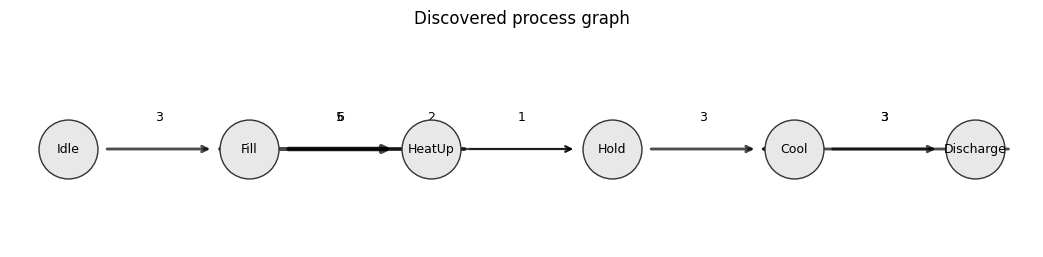

In [19]:

def compute_dfg(event_log_df):
    transitions = []
    for case_id, case_df in event_log_df.groupby("case_id"):
        ordered = case_df.sort_values("activity_sequence")
        activities = ordered["activity"].tolist()
        for a, b in zip(activities, activities[1:]):
            transitions.append((a, b))
    return (
        pd.DataFrame(transitions, columns=["source", "target"])
        .value_counts().reset_index(name="count").sort_values("count", ascending=False)
    )


def plot_process_graph(dfg, node_order):
    fig, ax = plt.subplots(figsize=(max(10, len(node_order) * 2.2), 2.8))
    ax.axis("off")
    step = 2.5
    x_pos = {node: i * step for i, node in enumerate(node_order)}
    max_count = dfg["count"].max()
    for _, row in dfg.iterrows():
        x0, x1 = x_pos[row["source"]], x_pos[row["target"]]
        width = 0.8 + 2.5 * (row["count"] / max_count)
        ax.annotate("", xy=(x1 - 0.5, 0), xytext=(x0 + 0.5, 0),
                    arrowprops=dict(arrowstyle="->", linewidth=width, alpha=0.7))
        ax.text((x0 + x1) / 2, 0.15, str(row["count"]), ha="center", fontsize=9)
    for node in node_order:
        x = x_pos[node]
        ax.scatter([x], [0], s=1800, color="#e8e8e8", edgecolor="#333333", zorder=3)
        ax.text(x, 0, node, ha="center", va="center", fontsize=9, zorder=4)
    ax.set_xlim(-0.8, (len(node_order) - 1) * step + 0.8)
    ax.set_ylim(-0.5, 0.6)
    ax.set_title("Discovered process graph")
    plt.show()


dfg = compute_dfg(event_log.to_dataframe())
plot_process_graph(dfg, STATE_ORDER)



That's a process model, discovered from sensor data, with no human ever drawing an arrow. Given the flickering
discussed above, don't be surprised to see a few extra, thinner edges alongside the main `Idle -> Fill -> HeatUp
-> Hold -> Cool -> Discharge` chain -- the thick edges are the dominant, "real" transitions, and the thin ones
are exactly the noisy segments that `min_duration_seconds` filtering (Try it yourself, below) is meant to
remove.



## Try it yourself 🔧

Spend five minutes breaking (and fixing) something before moving on:

1. Change `min_duration_seconds` from `0.0` to `90.0` in Step 6 and re-run Steps 6-8. What happens to the event
   count, and to `activity_frequencies`?
2. Delete the `hold_rule` from `feature_plan` in Step 5 and re-run from there. Does `Hold` join
   `diagnostics["unexplainable_states"]` now?
3. Go back to Step 3e and change `n_batches=3` to `n_batches=8`. Does the HMM's decoding accuracy (visible in
   the printed classification report in Step 6) tend to improve with more data? Why might that be?

<details>
<summary>Hints, if you get stuck</summary>

1. On this dataset, raising `min_duration_seconds` to `90.0` drops the event count noticeably -- but check
   `activity_frequencies` afterward: a genuinely short state like `Cool` can disappear from the log entirely if
   the threshold is too aggressive. There's no universally "correct" value; it's a judgment call a domain expert
   should make based on how short real states are allowed to be.
2. Yes -- with no rule referencing high, stable temperature, `Hold` loses its only real signal and should join
   the unexplainable list.
3. More batches generally means more training examples for the HMM to learn each state's typical feature
   pattern from, which tends to produce more stable, less "flickery" decoding -- though with unsupervised mode,
   results can still vary between runs since there's no ground truth guiding training.
</details>



## Go further with real data (optional)

Once the exercises above feel comfortable, try pointing a feature plan at real sensor data instead of our
synthetic batches:

- [NASA C-MAPSS turbofan degradation dataset](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) --
  21 real sensor channels per engine cycle. A natural first exercise: treat each engine's full run as one
  "batch," and see whether a `stability`/`temporal` feature pair can distinguish early-life operation from
  late-life degradation.
- [Smart Manufacturing IoT-Cloud dataset](https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset) --
  the `Machine_Status` column (Idle / Running / Failure) gives you a rough ground truth to check your own
  feature plan against, the same way our `state` column let us check ours here.

Both are considerably messier than our synthetic dataset -- which is exactly the point, once you're ready for
it.



## Recap, and what's next

You just built a synthetic industrial dataset from first principles, engineered features for it family by
family, ran the complete Sensor2EventLog pipeline, and visualized the discovered process -- understanding *why*
at each step, not just *how*.

### Where this tutorial series goes from here

| Level | Notebook | What it covers |
|---|---|---|
| 0 | [`tutorials/level_0_concepts/`](../tutorials/level_0_concepts/level_0_concepts.ipynb) | Event logs vs. sensor streams, in general |
| 1 | *You are here* | Your first end-to-end Sensor2EventLog run, step by step |
| 1.5 | `tutorials/level_1_5_first_event_log/` | Build your own event log from a plain CSV with 2-3 rules |
| 2 | `tutorials/level_2_*` | The Machine Teaching loop in depth, supervised vs. unsupervised HMMs, the event-predicate DSL |
| 3 | `tutorials/level_3_*` | The real pasteurization case, eventization-quality evaluation, full PM4Py integration |

See the tutorials table in the project [README](../README.md) for links as later levels come online.
